# Lab 4
## Beamforming

# Part 1 
Here initially study narrowband beamforming and how investigate how different parameters influence the output of the beamformer. We build a class which will implement the beamformer to a narrowband signal which will be used as our base class in which we will be able to compare this against our later study in this lab. Our class assumes a Uniform Linear Array (ULA) with angles in radians and spacing in wavelengths.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.makedirs('images', exist_ok=True)

### Conventions
- The array is a Uniform Linear Array (ULA).
- Angles are in radians unless a variable name ends in `_deg`.
- Element spacing `d` is expressed in wavelengths.
- For this convention, the steering phase term is based on `2*pi*d*n*sin(theta)`.


In [2]:
class NarrowbandBeamformer:
    def __init__(self, n_elements, d=0.5, window="rect"):
        """
        n_elements : int
            Number of ULA elements.
        d : float
            Element spacing in wavelengths.
        window : {"rect", "hann", "hamming"}
            Spatial window applied across the array.
        """
        self.N = n_elements
        self.d = d
        self.n = np.arange(self.N)

        self.window = self._make_window(window)

        self.theta_steer = 0.0
        self.w = None
        self.steer(self.theta_steer)

    def _make_window(self, window):
        """
        Return a 1D window array of shape (N,).

        TODO
        Implement the following window types:
        "rect"
        "hann"
        "hamming"

        Then normalise the window so its maximum magnitude is 1.
        """
        if window == "rect":
            win = np.ones(self.N)
        elif window == "hann":
            win = np.hanning(self.N)
        elif window == "hamming":
            win = np.hamming(self.N)
        else:
            raise ValueError(f"Unknown window type: {window}")
        
        return win / np.max(np.abs(win))

    def update_weights(self):
        """
        Update the beamformer weights for the current steering angle.

        TODO
        Compute the steering vector at `self.theta_steer`.
        Apply the window elementwise.
        Store the result in `self.w`.

        Expected shape:
        self.w : (N,)
        """
        a = self.steering_vector(self.theta_steer)
        self.w = self.window * a

    def steering_vector(self, theta):
        """
        ULA steering vector for spacing in wavelengths.

        For this lab convention:
            a_n(theta) = exp(j * 2*pi*d*n*sin(theta))

        theta : float or ndarray
            Angle in radians.

        a : ndarray

        TODO
        Use an outer product so this works for both scalar and vector theta.
        """
        theta_arr = np.atleast_1d(theta)
        
        phase = 2 * np.pi * self.d * np.outer(self.n, np.sin(theta_arr))
        a = np.exp(1j * phase)
        
        if a.shape[1] == 1:
            return np.squeeze(a)
        return a

    def steer(self, theta):
        """
        Store the steering angle and update the weights.
        """
        self.theta_steer = theta
        self.update_weights()

    def beamform(self, X):
        """
        Apply the beamformer output y = w^H X.

        X : ndarray

        y : complex scalar or ndarray
            Beamformer output.

        TODO
        Implement the conjugate-transpose dot product.
        """
        return np.conj(self.w).T @ X

    def beampattern(self, theta_grid):
        """
        Compute the normalised power beampattern in dB over theta_grid.

        theta_grid : ndarray of shape (M,)
            Scan angles in radians.

        Returns
        P_db : ndarray of shape (M,)

        TODO
        Compute the array response B(theta) = w^H a(theta)
        Compute power |B|^2
        Normalise so the maximum is 1
        Convert to dB
        """
        A = self.steering_vector(theta_grid)
        B = np.conj(self.w).T @ A
        
        P = np.abs(B)**2
        P_norm = P / np.max(P)
        
        P_db = 10 * np.log10(P_norm + 1e-12)
        return P_db

    def doa_scan(self, X, theta_scan):
        """
        Scan over candidate directions and choose the best one.

        X : ndarray, shape (N, K)
            Array data.
        theta_scan : ndarray, shape (M,)
            Candidate scan angles in radians.

        Returns
        theta_hat : float
            Estimated DOA in radians.
        metric : ndarray, shape (M,)
            Scan metric value for each candidate angle.

        TODO
        For each scan angle:
        Steer the beamformer
        Beamform the data
        Compute a scalar metric, e.g. mean output power
        
        Then choose the angle that maximises the metric.
        """
        metric = np.zeros(len(theta_scan))
        
        for i, theta in enumerate(theta_scan):
            self.steer(theta)
            y = self.beamform(X)
            metric[i] = np.mean(np.abs(y)**2)
            
        best_idx = np.argmax(metric)
        theta_hat = theta_scan[best_idx]
        
        self.steer(self.theta_steer)
        
        return theta_hat, metric

Plot and investigate the effects of:

- Steering angles

- The effect of the number of elements

- The effect of the spacing 

- The effect of the window 

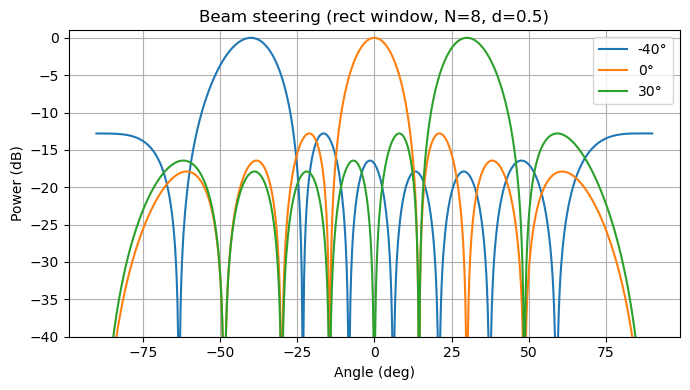

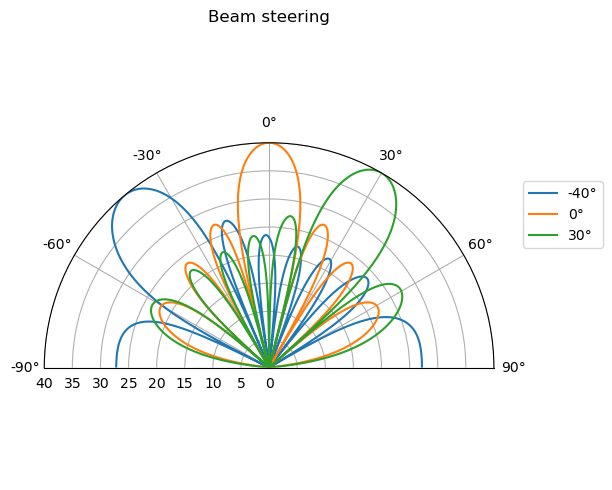

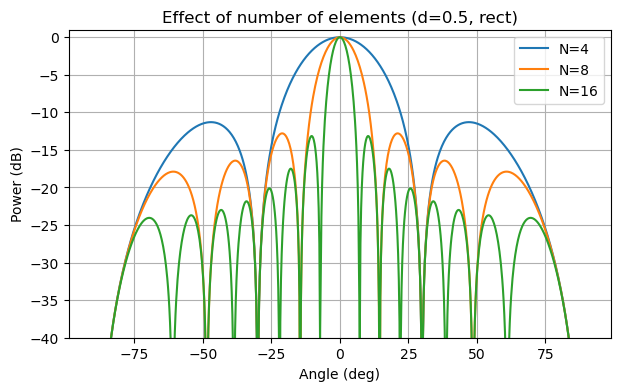

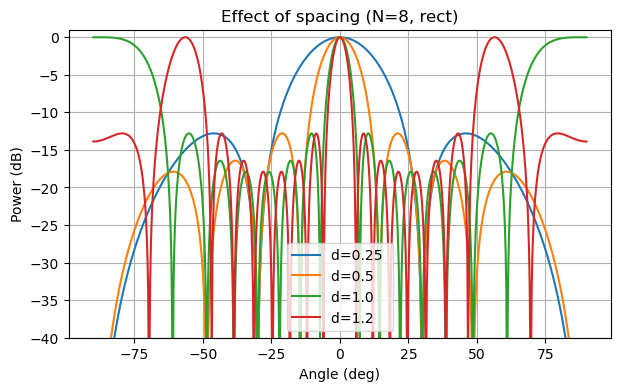

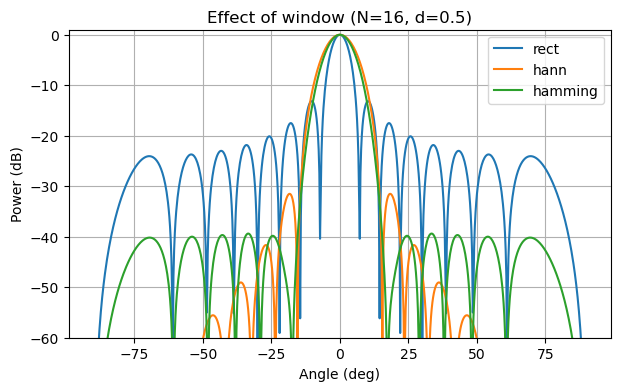

In [3]:

theta_grid = np.linspace(-np.pi/2, np.pi/2, 721)


bf = NarrowbandBeamformer(n_elements=8, d=0.5, window="rect")
steer_angles_deg = [-40, 0, 30]

plt.figure(figsize=(7, 4))
for th_deg in steer_angles_deg:
    bf.steer(theta=np.deg2rad(th_deg))
    P = bf.beampattern(theta_grid) 
    plt.plot(np.rad2deg(theta_grid), P, label=f"{th_deg}°")
plt.xlabel("Angle (deg)")
plt.ylabel("Power (dB)")
plt.title("Beam steering (rect window, N=8, d=0.5)")
plt.ylim([-40, 1])
plt.grid(True)
plt.legend()
plt.tight_layout()

fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(6, 5))
for th_deg in steer_angles_deg:
    bf.steer(theta=np.deg2rad(th_deg))
    P = bf.beampattern(theta_grid)  
    P_clip = np.clip(P, -40, 0)
    r = P_clip + 40
    ax.plot(theta_grid, r, label=f"{th_deg}°")

ax.set_theta_zero_location("N")   
ax.set_theta_direction(-1)     
ax.set_thetamin(-90)
ax.set_thetamax(90)
ax.set_rmax(40)
ax.set_title("Beam steering")

ax.legend(loc="lower left", bbox_to_anchor=(1.05, 0.5))
plt.tight_layout()


plt.figure(figsize=(7, 4))
for N in [4, 8, 16]:
    bfN = NarrowbandBeamformer(n_elements=N, d=0.5, window="rect")
    bfN.steer(theta=0.0)  
    P = bfN.beampattern(theta_grid)
    plt.plot(np.rad2deg(theta_grid), P, label=f"N={N}")
plt.xlabel("Angle (deg)")
plt.ylabel("Power (dB)")
plt.title("Effect of number of elements (d=0.5, rect)")
plt.ylim([-40, 1])
plt.grid(True)
plt.legend()


plt.figure(figsize=(7, 4))
for d in [0.25, 0.5, 1.0, 1.2]:
    bf_d = NarrowbandBeamformer(n_elements=8, d=d, window="rect")
    bf_d.steer(theta=0.0)
    P = bf_d.beampattern(theta_grid)
    plt.plot(np.rad2deg(theta_grid), P, label=f"d={d} ")
plt.xlabel("Angle (deg)")
plt.ylabel("Power (dB)")
plt.title("Effect of spacing (N=8, rect)")
plt.ylim([-40, 1])
plt.grid(True)
plt.legend()

plt.figure(figsize=(7, 4))
windows = ["rect", "hann", "hamming"]
for win in windows:
    bf_w = NarrowbandBeamformer(n_elements=16, d=0.5, window=win)
    bf_w.steer(theta=0.0)
    P = bf_w.beampattern(theta_grid)
    plt.plot(np.rad2deg(theta_grid), P, label=win)
plt.xlabel("Angle (deg)")
plt.ylabel("Power (dB)")
plt.title("Effect of window (N=16, d=0.5)")
plt.ylim([-60, 1])
plt.grid(True)
plt.legend()

plt.show()

In [5]:
def simulate_narrowband_ula_simple(N, d, theta_deg, n_samples=2000,
                                   noise_std=0.5, f0=0.05):
    """
    Simulate a single narrowband plane wave arriving at a ULA.

    N : int
        Number of array elements.
    d : float
        Element spacing.
    theta_deg : float
        Source direction in degrees.
    n_samples : int
        Number of time samples.
    noise_std : float
        Noise standard deviation.
    wavelength : float
        Wavelength used by the beamformer model.
    f0 : float
        Normalised temporal frequency of the source.

    Returns
    X : ndarray, shape (N, n_samples)
        Simulated complex array data.

    Notes
    This helper uses your `NarrowbandBeamformer.steering_vector`
    implementation to generate the spatial signature of the source.
    """
    bf = NarrowbandBeamformer(n_elements=N, d=d)

    theta = np.deg2rad(theta_deg)

    # TODO:
    # Compute the steering vector for the source direction.
    # Expected shape: (N,)
    a = bf.steering_vector(theta)

    t = np.arange(n_samples)

    # TODO:
    # Generate a complex narrowband tone s with shape (n_samples,)
    # using frequency f0.
    s = np.exp(1j * 2 * np.pi * f0 * t)

    # TODO:
    # Form the noise-free array data X_sig with shape (N, n_samples)
    # using the spatial steering vector and temporal signal.
    X_sig = np.outer(a, s)

    n = np.random.randn(*X_sig.shape) + 1j * np.random.randn(*X_sig.shape)
    X = X_sig + noise_std * n
    return X

True DOA: 20.0 deg
Estimated DOA: 20.00 deg


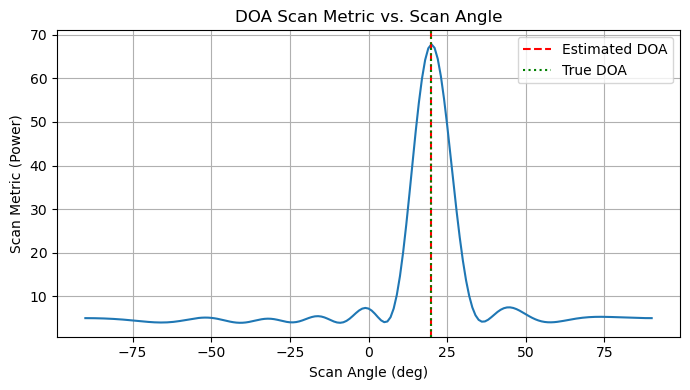

In [6]:
N = 8
d = 0.5
theta_true_deg = 20

X = simulate_narrowband_ula_simple(
    N=N,
    d=d,
    theta_deg=theta_true_deg,)

# After implementing the DOA scan in your beamformer class,
# use it here to estimate the source direction.
bf = NarrowbandBeamformer(n_elements=N, d=d, window="rect")

theta_scan = np.linspace(-np.pi/2, np.pi/2, 181)

# TODO:
# Run the DOA scan over theta_scan.
# Store the estimated angle in theta_hat
# and the scan metric in metric.
theta_hat, metric = bf.doa_scan(X, theta_scan)

# TODO:
# Compare the true DOA and the estimated DOA.
# Print both in degrees.
# Example variable names:
#   theta_true_deg
#   theta_hat
#
# Uncomment when ready:
print(f"True DOA: {theta_true_deg:.1f} deg")
print(f"Estimated DOA: {np.rad2deg(theta_hat):.2f} deg")

# TODO:
# Plot scan angle (in degrees) against the scan metric.
# Label the axes and add a title.

plt.figure(figsize=(7, 4))
plt.plot(np.rad2deg(theta_scan), metric)
plt.axvline(np.rad2deg(theta_hat), color='r', linestyle='--', label='Estimated DOA')
plt.axvline(theta_true_deg, color='g', linestyle=':', label='True DOA')
plt.xlabel("Scan Angle (deg)")
plt.ylabel("Scan Metric (Power)")
plt.title("DOA Scan Metric vs. Scan Angle")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
def steering_vector(N, d, theta_rad):
    """
    ULA steering vector for spacing d measured in wavelengths.

    N : int
        Number of array elements.
    d : float
        Element spacing in wavelengths.
    theta_rad : float
        Look direction in radians.

    Returns
    a : ndarray, shape (N,)

    TODO
    Implement the steering vector using the same convention as earlier
    in the lab.
    """
    n = np.arange(N)
    return np.exp(1j * 2 * np.pi * d * n * np.sin(theta_rad))


# Conventional beamformer weights
def w_conventional(N, d, theta_steer_rad, window=None):
    """
    Conventional beamformer weights.

    N : int
        Number of array elements.
    d : float
        Element spacing in wavelengths.
    theta_steer_rad : float
        Steering direction in radians.
    window : ndarray or None
        Spatial window of shape (N,).

    Returns
    w : ndarray, shape (N,)

    TODO
    Compute the steering vector at theta_steer_rad
    Apply the window elementwise
    """
    if window is None:
        window = np.ones(N)

    a = steering_vector(N, d, theta_steer_rad)
    return window * a


# MVDR weights
def w_mvdr(N, d, theta_steer_rad, X, diagonal_loading=1e-3):
    """
    MVDR beamformer:
        w = R^{-1} a / (a^H R^{-1} a)
    N : int
        Number of array elements.
    d : float
        Element spacing in wavelengths.
    theta_steer_rad : float
        Steering direction in radians.
    X : ndarray, shape (N, K)
        Array data with K snapshots.
    diagonal_loading : float
        Small positive regularisation term for numerical stability.

    Returns
    w : ndarray, shape (N,)
        MVDR weight vector.
    R : ndarray, shape (N, N)
        Loaded covariance matrix.

    TODO
    Estimate the sample covariance matrix R from X
    Add diagonal loading to R
    Compute the steering vector a(theta_steer_rad)
    Solve the linear system for R^{-1} a
    Compute the scalar denominator a^H R^{-1} a
    Form and return the MVDR weights
    """
    X = np.asarray(X)
    K = X.shape[1]

    R = (X @ np.conj(X).T) / K
    R += diagonal_loading * np.eye(N)
    
    a = steering_vector(N, d, theta_steer_rad)
    
    R_inv_a = np.linalg.solve(R, a)
    den = np.conj(a).T @ R_inv_a
    w = R_inv_a / den
    
    return w, R


def apply_beamformer(w, X):
    """
    Apply beamformer output y = w^H X.

    w : ndarray, shape (N,)
        Beamformer weights.
    X : ndarray, shape (N,) or (N, K)
        Input array data.

    Returns
    y : complex scalar or ndarray

    TODO
    Implement the conjugate-transpose beamformer product.
    """
    return np.conj(w).T @ X


def beampattern(N, d, w, theta_grid):
    """
    Compute normalised beampattern in dB.
    N : int
    d : float
    w : ndarray, shape (N,)
    theta_grid : ndarray, shape (M,)

    Returns
    P_db : ndarray, shape (M,)
    """
    A = np.stack([steering_vector(N, d, th) for th in theta_grid], axis=1)  # (N, nTheta)
    B = np.conj(w) @ A
    P = np.abs(B) ** 2
    P /= np.max(P) + 1e-12
    P_db = 10 * np.log10(np.maximum(P, 1e-12))
    return P_db


# Simulate two plane waves
def simulate_two_tone_ula(N, d,
                          theta_des_deg, theta_int_deg,
                          f_des=0.02, f_int=0.02,
                          A_des=1.0, A_int=1.0,
                          n_samples=2000,
                          noise_std=0.05,
                          seed=0):
    """
    Simulate a desired source and an interferer impinging on a ULA.

    Returns
    X : ndarray, shape (N, n_samples)
        Total received array data
    X_des : ndarray, shape (N, n_samples)
        Desired-signal component only
    X_int : ndarray, shape (N, n_samples)
        Interference component only

    TODO
    Use steering vectors for the desired and interfering directions,
    then combine the spatial and temporal signals with additive noise.
    """
    rng = np.random.default_rng(seed)
    t = np.arange(n_samples)

    th_des = np.deg2rad(theta_des_deg)
    th_int = np.deg2rad(theta_int_deg)

    a_des = steering_vector(N, d, th_des).reshape(-1, 1)
    a_int = steering_vector(N, d, th_int).reshape(-1, 1)

    s_des = (A_des * np.exp(1j * 2 * np.pi * f_des * t)).reshape(1, -1)
    s_int = (A_int * np.exp(1j * 2 * np.pi * f_int * t)).reshape(1, -1)

    X_des = a_des @ s_des
    X_int = a_int @ s_int

    noise = (
        rng.normal(0, 1, size=(N, n_samples))
        + 1j * rng.normal(0, 1, size=(N, n_samples))
    )
    X = X_des + X_int + noise_std * noise

    return X, X_des, X_int


def output_sinr_db(y_total, y_des, y_int):
    """
    Compute output SINR in dB.

    y_total : ndarray
        Beamformer output for total received data.
    y_des : ndarray
        Beamformer output for desired-signal component.
    y_int : ndarray
        Beamformer output for interference component.

    Returns
    sinr_db : float

    TODO
    Estimate the residual noise term from y_total, y_des, and y_int
    Compute desired, interference, and noise powers
    Return output SINR in dB
    """
    y_noise = y_total - y_des - y_int
    p_des = np.mean(np.abs(y_des)**2)
    p_int = np.mean(np.abs(y_int)**2)
    p_noise = np.mean(np.abs(y_noise)**2)
    sinr = p_des / (p_int + p_noise)
    return 10 * np.log10(sinr)

Desired angle:     +20.0 deg
Interferer angle:  +25.0 deg
Output SINR (Conventional): -12.47 dB
Output SINR (MVDR):         -0.13 dB


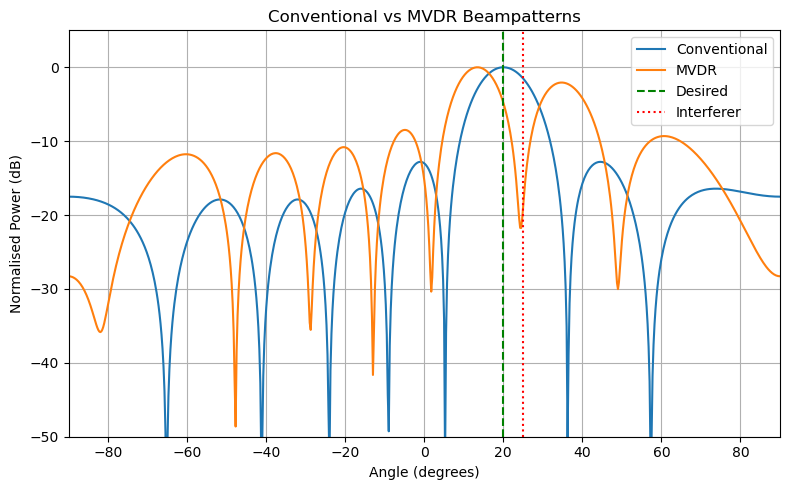

In [8]:
N = 8
d = 0.5  # element spacing in wavelengths

theta_des_deg = 20
theta_int_deg = 25

A_des = 1.0
A_int = 5.0

X, X_des, X_int = simulate_two_tone_ula(
    N=N, d=d,
    theta_des_deg=theta_des_deg,
    theta_int_deg=theta_int_deg,
    f_des=0.02, f_int=0.02,
    A_des=A_des, A_int=A_int,
    n_samples=4000,
    noise_std=0.2,
    seed=0
)

theta0 = np.deg2rad(theta_des_deg)
theta_grid = np.deg2rad(np.linspace(-90, 90, 721))

# Conventional beamformer
w_conv = w_conventional(N, d, theta0, window=np.ones(N))
y_conv = apply_beamformer(w_conv, X)
y_conv_des = apply_beamformer(w_conv, X_des)
y_conv_int = apply_beamformer(w_conv, X_int)

# MVDR beamformer
w_mv, R = w_mvdr(N, d, theta0, X, diagonal_loading=1e-2)
y_mv = apply_beamformer(w_mv, X)
y_mv_des = apply_beamformer(w_mv, X_des)
y_mv_int = apply_beamformer(w_mv, X_int)

# Beampatterns
P_conv = beampattern(N, d, w_conv, theta_grid)
P_mvdr = beampattern(N, d, w_mv, theta_grid)

# TODO:
# Compute the output SINR for the conventional and MVDR beamformers.
# Store them in variables named:
#   sinr_conv
#   sinr_mvdr
sinr_conv = output_sinr_db(y_conv, y_conv_des, y_conv_int)
sinr_mvdr = output_sinr_db(y_mv, y_mv_des, y_mv_int)

# Uncomment after computing sinr_conv and sinr_mvdr
print(f"Desired angle:     {theta_des_deg:+.1f} deg")
print(f"Interferer angle:  {theta_int_deg:+.1f} deg")
print(f"Output SINR (Conventional): {sinr_conv:.2f} dB")
print(f"Output SINR (MVDR):         {sinr_mvdr:.2f} dB")

# TODO:
# Plot the conventional and MVDR beampatterns on the same axes.
# Also mark the desired and interfering angles.
#
# Suggested plot elements:
# x-axis: angle in degrees
# y-axis: normalised power in dB

plt.figure(figsize=(8, 5))
plt.plot(np.rad2deg(theta_grid), P_conv, label="Conventional")
plt.plot(np.rad2deg(theta_grid), P_mvdr, label="MVDR")
plt.axvline(theta_des_deg, color="green", linestyle="--", label="Desired")
plt.axvline(theta_int_deg, color="red", linestyle=":", label="Interferer")
plt.xlabel("Angle (degrees)")
plt.ylabel("Normalised Power (dB)")
plt.title("Conventional vs MVDR Beampatterns")
plt.ylim([-50, 5])
plt.xlim([-90, 90])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Questions
1. For steering angles , where does the mainlobe point in the beampattern plot? Explain how the steering vector phase term $2\pi d n \sin(\theta)$ causes the beam to aim in that direction.
2. Compare the beampatterns for $N=\{4,8,16\}$ at d=0.5.
	- What happens to the mainlobe width as N increases?
	- What happens to the sidelobe structure?
3. Compare $d=\{0.25,0.5,1.0,1.2\}$ with N=8.
	- At which spacing do you start seeing additional strong lobes?
	- Why does spacing larger than about $\lambda/2$ cause ambiguous directions?
4.	With N=16 and d=0.5, compare rect, hann, and hamming.
	- What cost do you pay in the mainlobe (width / peak sharpness)?
5.	Conventional DOA scan vs MVDR in two-source case
In the two-tone simulation ($20^\circ$ desired, $25^\circ$ interferer), compare conventional beam steering and MVDR:
	- Using your beampattern or DOA metric, explain why conventional struggles to suppress the interferer when angles are close.
	- Report the output SINR for both methods and explain why MVDR improves it.


In [9]:
def band_limited_noise(N, fs, f_lo=50, f_hi=10000, seed=None):
    """
    Generate real-valued band-limited noise.

    N : int
        Number of samples.
    fs : float
        Sample rate in Hz.
    f_lo, f_hi : float
        Lower and upper band edges in Hz.
    seed : int or None
        Random seed.

    Returns
    x_bl : ndarray, shape (N,)
        Band-limited noise with approximately unit standard deviation.
    """
    rng = np.random.default_rng(seed)
    x = rng.standard_normal(N)
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(N, 1 / fs)
    mask = (freqs >= f_lo) & (freqs <= f_hi)
    X[~mask] = 0
    x_bl = np.fft.irfft(X, n=N)
    x_bl /= (np.std(x_bl) + 1e-12)
    return x_bl


def frac_delay_2tap(x, D):
    """
    Delay a signal by D samples using a simple 2-tap FIR fractional delay.

    Model
    If D = m + a, where:
      m is the integer part
      a is the fractional part in [0, 1)

    then the delayed signal can be approximated by:
      y[n] = (1-a) x[n-m] + a x[n-m-1]


    x : ndarray, shape (N,)
        Input signal.
    D : float
        Desired delay in samples. Assume D >= 0 for this function.

    Returns

    y : ndarray, shape (N,)

    TODO

    Compute the integer delay m and fractional part a
    Build the delayed versions x_m and x_m1 using zero-padding
    Return the weighted combination:
           (1-a) * x_m + a * x_m1
    """
    x = np.asarray(x)

    m = int(np.floor(D))
    a = D - m
    
    x_m = np.zeros_like(x)
    if m < len(x):
        x_m[m:] = x[:-m] if m > 0 else x
        
    x_m1 = np.zeros_like(x)
    if m + 1 < len(x):
        x_m1[m+1:] = x[:-(m+1)]
        
    y = (1 - a) * x_m + a * x_m1
    return y


def add_awgn(x, snr_db, seed=None):
    """
    Add white Gaussian noise to achieve a target SNR.

    x : ndarray
        Input real-valued signal.
    snr_db : float
        Signal-to-noise ratio in dB.
    seed : int or None
        Random seed.

    Returns
    y : ndarray
        Noisy signal.
    """
    rng = np.random.default_rng(seed)
    p_sig = np.mean(x**2)
    p_noise = p_sig / (10 ** (snr_db / 10))
    return x + np.sqrt(p_noise) * rng.standard_normal(len(x))


def gcc_phat(x, y, fs, max_tau=None, interp=16):
    """
    GCC-PHAT time-delay estimator.

    Parameters
    x, y : ndarray, shape (N,)
        Input microphone signals.
    fs : float
        Sample rate in Hz.
    max_tau : float or None
    interp : int
        Interpolation factor applied in the correlation domain.

    Returns
    tau_hat : float
        Estimated delay in seconds.
    cc : ndarray
        GCC-PHAT correlation sequence around zero lag.
    lags : ndarray
        Lag axis in seconds, same length as cc.

    TODO
    Compute one-sided FFTs of x and y
    Form the cross-spectrum R = X * conj(Y)
    Apply PHAT weighting
    Compute the correlation by inverse FFT, using interpolation
    Restrict to the lag window around zero
    Find the lag of the largest peak magnitude
    Convert that lag into seconds
    Build the lag axis in seconds
    """
    x = np.asarray(x)
    y = np.asarray(y)

    n = len(x) + len(y)

    X = np.fft.rfft(x, n=n)
    Y = np.fft.rfft(y, n=n)
    
    R = X * np.conj(Y)
    R /= (np.abs(R) + 1e-12)
    
    n_interp = n * interp
    cc = np.fft.irfft(R, n=n_interp)
    cc = np.fft.fftshift(cc)
    
    lags = np.arange(-n_interp // 2, n_interp // 2) / (fs * interp)
    
    if max_tau is not None:
        valid_idx = np.abs(lags) <= max_tau
        cc = cc[valid_idx]
        lags = lags[valid_idx]
        
    tau_hat = lags[np.argmax(np.abs(cc))]
    
    return tau_hat, cc, lags

In [10]:
def simulate_two_mic_signals(theta_deg, fs=16000, T=1.0, d=0.08, c=343.0, snr_db=10, seed=0):
    N = int(fs * T)
    s = band_limited_noise(N, fs, seed=seed)

    theta = np.deg2rad(theta_deg)
    tau = (d * np.sin(theta)) / c            # seconds
    D = tau * fs                              # samples 

    # mic0 is reference; mic1 is delayed if tau > 0
    x0 = s.copy()

    if D >= 0:
        x1 = frac_delay_2tap(s, D)

    else:
        x0 = frac_delay_2tap(s, -D)
        x1 = s.copy()


    x0 = add_awgn(x0, snr_db, seed=seed+1)
    x1 = add_awgn(x1, snr_db, seed=seed+2)

    return x0, x1, tau

theta_true = +30.0 deg
tau_true   = +116.62 us
tau_hat    = -121.09 us


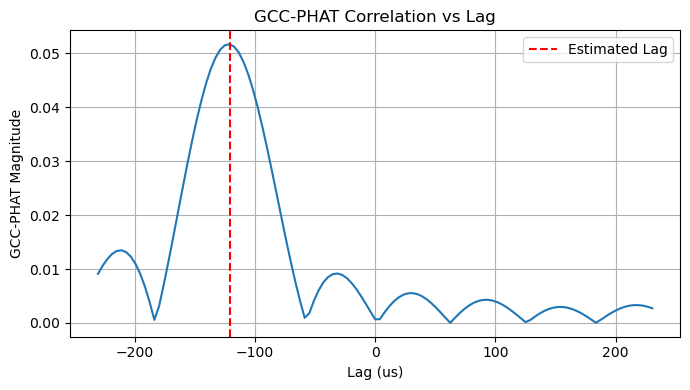

In [11]:
fs = 16000
d = 0.08
c = 343.0
theta_deg = 30
snr_db = 10

x0, x1, tau_true = simulate_two_mic_signals(
    theta_deg,
    fs=fs,
    T=1.0,
    d=d,
    c=c,
    snr_db=snr_db,
    seed=1
)

max_tau = d / c

# TODO:
# Call your GCC-PHAT function and store the outputs in:
#   tau_hat, cc, lags
tau_hat, cc, lags = gcc_phat(x0, x1, fs, max_tau=max_tau)

# TODO:
# Compare and print:
# - true angle
# - true delay
# - estimated GCC-PHAT delay
#
# Uncomment when ready:
print(f"theta_true = {theta_deg:+.1f} deg")
print(f"tau_true   = {tau_true*1e6:+.2f} us")
print(f"tau_hat    = {tau_hat*1e6:+.2f} us")

# TODO:
# Plot the GCC-PHAT correlation magnitude versus lag in microseconds.
# Also mark the estimated lag with a vertical line.

plt.figure(figsize=(7,4))
plt.plot(lags * 1e6, np.abs(cc))
plt.axvline(tau_hat * 1e6, color='r', linestyle='--', label='Estimated Lag')
plt.xlabel('Lag (us)')
plt.ylabel('GCC-PHAT Magnitude')
plt.title('GCC-PHAT Correlation vs Lag')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
def tau_to_theta(tau, d, c=343.0):
    """
    Convert a time delay to arrival angle for a two-microphone array.

    tau : float or ndarray
        Inter-microphone delay in seconds.
    d : float
        Microphone spacing in metres.
    c : float
        Speed of sound in m/s.

    Returns
    theta : float or ndarray
        Angle in radians.
    """
    val = np.clip((c * tau) / d, -1.0, 1.0)
    return np.arcsin(val)

In [13]:
# TODO:
# Convert the previously estimated delay tau_hat into an angle estimate.
# Store the result in degrees in a variable named theta_hat.
theta_hat = np.rad2deg(tau_to_theta(tau_hat, d, c))

# Uncomment when ready:
print(f"theta_hat  = {theta_hat:+.2f} deg")

theta_hat  = -31.28 deg


In [14]:
angles = [-30, 20, 60]
snrs = [20, 0]

# TODO:
# Compare the true theta and tau with the GCC-PHAT estimates
# for different angles and SNR values.
#
# For each case:
# simulate the two microphone signals
# estimate tau_hat using gcc_phat(...)
# convert tau_hat into theta_hat
# store the results in the list `results`
results = []

for th in angles:
    for snr in snrs:
        seed = (th + 90) + snr

        x0, x1, tau_true = simulate_two_mic_signals(
            th, fs=fs, T=0.05, d=d, c=c, snr_db=snr, seed=seed
        )

        # TODO:
        # Estimate tau_hat using GCC-PHAT.
        # Restrict the lag search using max_tau=d/c.
        tau_hat, _, _ = gcc_phat(x0, x1, fs, max_tau=d/c)

        # TODO:
        # Convert tau_hat into an angle estimate in degrees.
        th_hat = np.rad2deg(tau_to_theta(tau_hat, d, c))

        results.append((
            th,
            snr,
            tau_true * 1e6,
            tau_hat * 1e6,
            th_hat,
            abs(th_hat - th),
        ))

print("theta_true  SNR(dB)  tau_true(us)  tau_hat(us)  theta_hat(deg)  abs_err(deg)")
for r in results:
    print(f"{r[0]:>+9.1f}  {r[1]:>6.1f}  {r[2]:>11.2f}  {r[3]:>10.2f}  {r[4]:>13.2f}  {r[5]:>12.2f}")

theta_true  SNR(dB)  tau_true(us)  tau_hat(us)  theta_hat(deg)  abs_err(deg)
    -30.0    20.0      -116.62      121.09          31.28         61.28
    -30.0     0.0      -116.62      117.19          30.16         60.16
    +20.0    20.0        79.77      -70.31         -17.55         37.55
    +20.0     0.0        79.77      -74.22         -18.55         38.55
    +60.0    20.0       201.99     -195.31         -56.87        116.87
    +60.0     0.0       201.99     -199.22         -58.67        118.67


In [15]:
def das_two_mic_scan(x0, x1, theta_grid, fs, d, c=343.0):
    """
    Two-microphone delay-and-sum scan.

    x0, x1 : ndarray, shape (N,)
        Microphone signals.
    theta_grid : ndarray
        Candidate angles in radians.
    fs : float
        Sample rate in Hz.
    d : float
        Microphone spacing in metres.
    c : float
        Speed of sound in m/s.

    Returns
    th_hat : float
        Estimated arrival angle in radians.
    P : ndarray
        Output power metric for each scan angle.

    TODO
    For each candidate angle:
    Compute the expected time delay tau
    Convert tau into a fractional sample delay D
    Align the two signals using frac_delay_2tap(...)
    Form the delay-and-sum output
    Compute a scalar power metric
    Select the angle that maximises the metric
    """
    P = np.zeros(theta_grid.shape, dtype=float)

    for i, th in enumerate(theta_grid):

        # TODO: compute expected delay tau from angle th
        tau = (d * np.sin(th)) / c

        # TODO: convert delay to samples
        D = tau * fs

        # TODO:
        # Align the signals using fractional delay.
        # One simple convention is:
        # if D >= 0, delay the earlier-arriving signal
        # else, delay the other signal
        if D >= 0:
            y0 = frac_delay_2tap(x0, D)
            y1 = x1
        else:
            y0 = x0
            y1 = frac_delay_2tap(x1, -D)
            
        y = y0 + y1

        # TODO: compute output power metric for this scan angle
        P[i] = np.mean(y**2)

    # TODO: choose the angle corresponding to the largest power
    th_hat = theta_grid[np.argmax(P)]
    
    return th_hat, P

In [16]:
def estimate_doa_gccphat(x0, x1, fs, d, c=343.0, interp=16):
    """
    Estimate DOA using GCC-PHAT.

    Returns
    theta_hat : float
        Estimated angle in degrees.
    tau_hat : float
        Estimated delay in seconds.
    """
    max_tau = d / c
    tau_hat, _, _ = gcc_phat(x0, x1, fs, max_tau=max_tau, interp=interp)
    theta_hat = np.rad2deg(tau_to_theta(tau_hat, d, c))
    return theta_hat, tau_hat


def estimate_doa_das(x0, x1, fs, d, c=343.0, grid_deg=None):
    """
    Estimate DOA using a two-microphone delay-and-sum scan.

    Returns
    theta_hat : float
        Estimated angle in degrees.
    tau_hat : float
        Delay corresponding to the chosen angle.
    P : ndarray
        Scan metric values.
    grid_deg : ndarray
        Scan grid in degrees.
    """
    if grid_deg is None:
        grid_deg = np.linspace(-90, 90, 361)

    theta_grid = np.deg2rad(grid_deg)

    th_hat_rad, P = das_two_mic_scan(x0, x1, theta_grid, fs, d, c=c)

    theta_hat = np.rad2deg(th_hat_rad)
    tau_hat = (d * np.sin(th_hat_rad)) / c
    
    return theta_hat, tau_hat, P, grid_deg

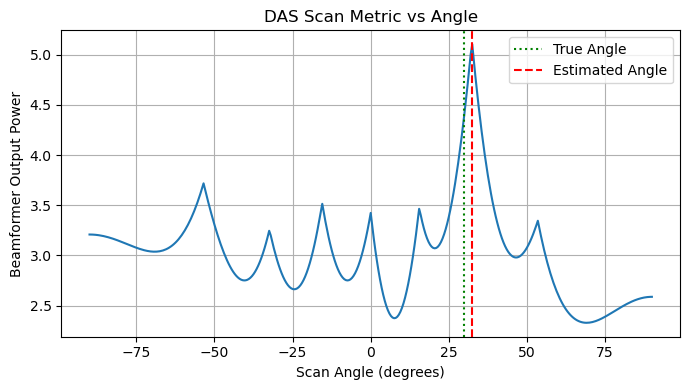

Scan-based theta_hat = +32.50 deg


In [17]:
fs = fs
d = d
c = c

theta_true = 30
snr_db = 0
T = 0.05

x0, x1, tau_true = simulate_two_mic_signals(
    theta_true, fs=fs, T=T, d=d, c=c, snr_db=snr_db, seed=100
)

grid_deg = np.linspace(-90, 90, 361)

theta_hat_das, tau_hat_das, P, grid_deg = estimate_doa_das(
    x0, x1, fs, d, c=c, grid_deg=grid_deg
)

plt.figure(figsize=(7, 4))
plt.plot(grid_deg, P)
plt.axvline(theta_true, color='g', linestyle=':', label='True Angle')
plt.axvline(theta_hat_das, color='r', linestyle='--', label='Estimated Angle')
plt.xlabel('Scan Angle (degrees)')
plt.ylabel('Beamformer Output Power')
plt.title('DAS Scan Metric vs Angle')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Scan-based theta_hat = {theta_hat_das:+.2f} deg")

In [18]:
angles = [-60, -30, 0, 20, 70]
snr_db = 10
T = 1.0

rows = []
for th in angles:
    seed = 5000 + (th + 90) * 10

    x0, x1, tau_true = simulate_two_mic_signals(
        th, fs=fs, T=T, d=d, c=c, snr_db=snr_db, seed=seed
    )

    theta_true = th

    theta_gcc, tau_gcc = estimate_doa_gccphat(x0, x1, fs, d, c=c)

    theta_das, tau_das, _, _ = estimate_doa_das(x0, x1, fs, d, c=c)

    rows.append((
        theta_true, snr_db,
        tau_true * 1e6,
        tau_gcc * 1e6, theta_gcc, abs(theta_gcc - theta_true),
        tau_das * 1e6, theta_das, abs(theta_das - theta_true)
    ))

print("th_true  SNR  tau_true(us) | tau_gcc(us)  th_gcc  err_gcc | tau_das(us)  th_das  err_das")
for r in rows:
    print(f"{r[0]:>+6.1f} {r[1]:>4.0f} {r[2]:>11.2f} | {r[3]:>10.2f} {r[4]:>7.2f} {r[5]:>7.2f} | {r[6]:>10.2f} {r[7]:>7.2f} {r[8]:>7.2f}")

th_true  SNR  tau_true(us) | tau_gcc(us)  th_gcc  err_gcc | tau_das(us)  th_das  err_das
 -60.0   10     -201.99 |     195.31   56.87  116.87 |    -187.49  -53.50    6.50
 -30.0   10     -116.62 |     121.09   31.28   61.28 |    -125.32  -32.50    2.50
  +0.0   10        0.00 |       0.00    0.00    0.00 |       0.00    0.00    0.00
 +20.0   10       79.77 |     -70.31  -17.55   37.55 |      62.33   15.50    4.50
 +70.0   10      219.17 |    -218.75  -69.70  139.70 |     187.49   53.50   16.50


Question 1

- In the GCC-PHAT plot, what does the peak location (lag) represent physically?



Question 2

- Run the simulation for the same angle  at two SNR values.

- What changes do you observe in the shape of the GCC-PHAT correlation peak and in the angle error?



Question 3

For the angle set [-60, -30, 0, 20, 70] at SNR = 10 dB, compare the DOA estimates from:


- GCC-PHAT 

- Two-mic delay-and-sum scan 

- Which method gives smaller error overall, and why might that be expected from how each method works?
